# 03. Churn Analysis

Overall churn/retention rates and churn by customer demographics, tenure, contract, services, payment method, charges and value segment. All rates are computed at runtime.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')

from src.data_cleaning import load_raw_data, clean_data
from src.segmentation import add_all_features
from src.churn_analysis import overall_churn, churn_by_group, analyze_all_dimensions

df = add_all_features(clean_data(load_raw_data())[0])

In [2]:
overall = overall_churn(df)
overall

{'total_customers': 7043,
 'churned_customers': 1869,
 'retained_customers': 5174,
 'churn_rate': 0.2653698707936959,
 'retention_rate': 0.7346301292063041}

In [3]:
def pct(x): return f'{x:.2%}'
print('Overall churn rate   :', pct(overall['churn_rate']))
print('Overall retention rate:', pct(overall['retention_rate']))
print(f"Churned: {overall['churned_customers']:,} of {overall['total_customers']:,}")

Overall churn rate   : 26.54%
Overall retention rate: 73.46%
Churned: 1,869 of 7,043


## Churn by dimension

In [4]:
churn_by_group(df, 'Contract').assign(
    churn_rate=lambda t: (t.churn_rate * 100).round(2),
    retention_rate=lambda t: (t.retention_rate * 100).round(2)
)

,Contract,customers,churned,retained,churn_rate,retention_rate
0,Month-to-month,3875,1655,2220,42.71,57.29
1,Two year,1695,48,1647,2.83,97.17
2,One year,1473,166,1307,11.27,88.73


In [5]:
churn_by_group(df, 'tenure_group').sort_values('customers', ascending=False)

,tenure_group,customers,churned,retained,churn_rate,retention_rate
0,0-6,1481,784,697,0.529372,0.470628
1,61+,1407,93,1314,0.066098,0.933902
2,13-24,1024,294,730,0.287109,0.712891
3,25-36,832,180,652,0.216346,0.783654
4,49-60,832,120,712,0.144231,0.855769
5,37-48,762,145,617,0.190289,0.809711
6,7-12,705,253,452,0.358865,0.641135


In [6]:
churn_by_group(df, 'InternetService')

,InternetService,customers,churned,retained,churn_rate,retention_rate
0,Fiber optic,3096,1297,1799,0.418928,0.581072
1,DSL,2421,459,1962,0.189591,0.810409
2,No,1526,113,1413,0.074050,0.925950


In [7]:
churn_by_group(df, 'PaymentMethod')

,PaymentMethod,customers,churned,retained,churn_rate,retention_rate
0,Electronic check,2365,1071,1294,0.452854,0.547146
1,Mailed check,1612,308,1304,0.191067,0.808933
2,Bank transfer (automatic),1544,258,1286,0.167098,0.832902
3,Credit card (automatic),1522,232,1290,0.152431,0.847569


## Charts

/workspace/customer-churn-analytics/src/visualization.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


/workspace/customer-churn-analytics/src/visualization.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


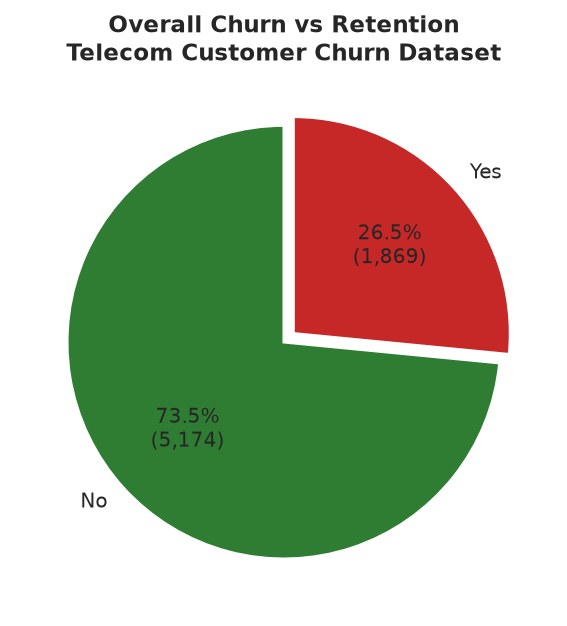

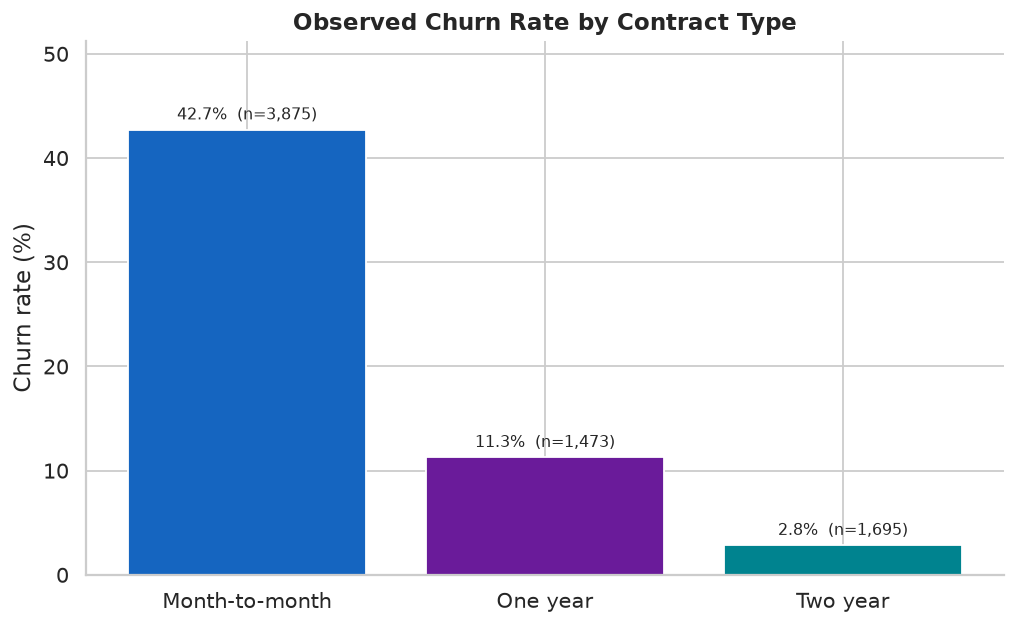

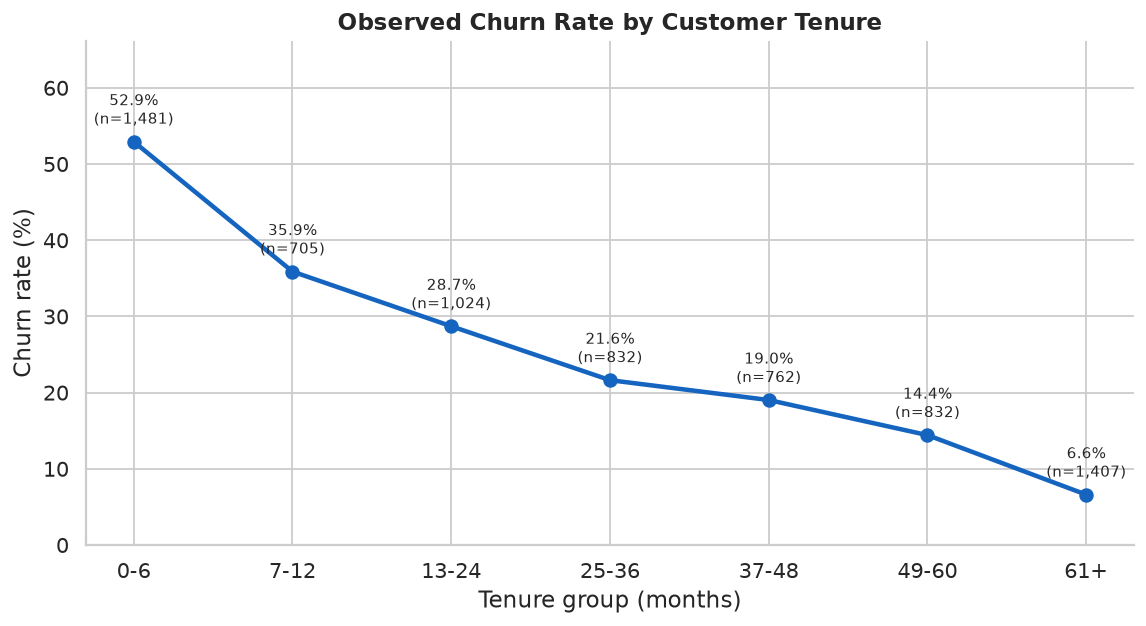

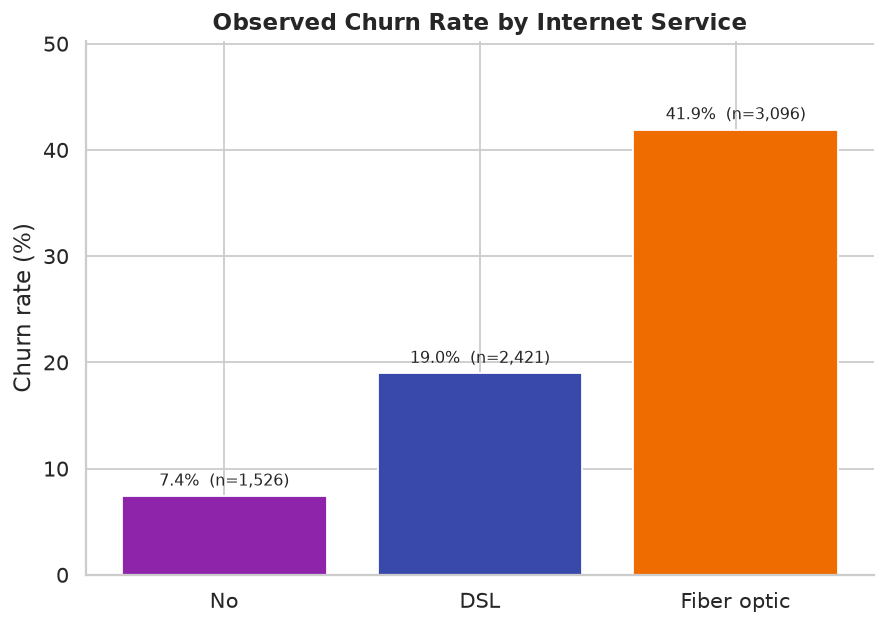

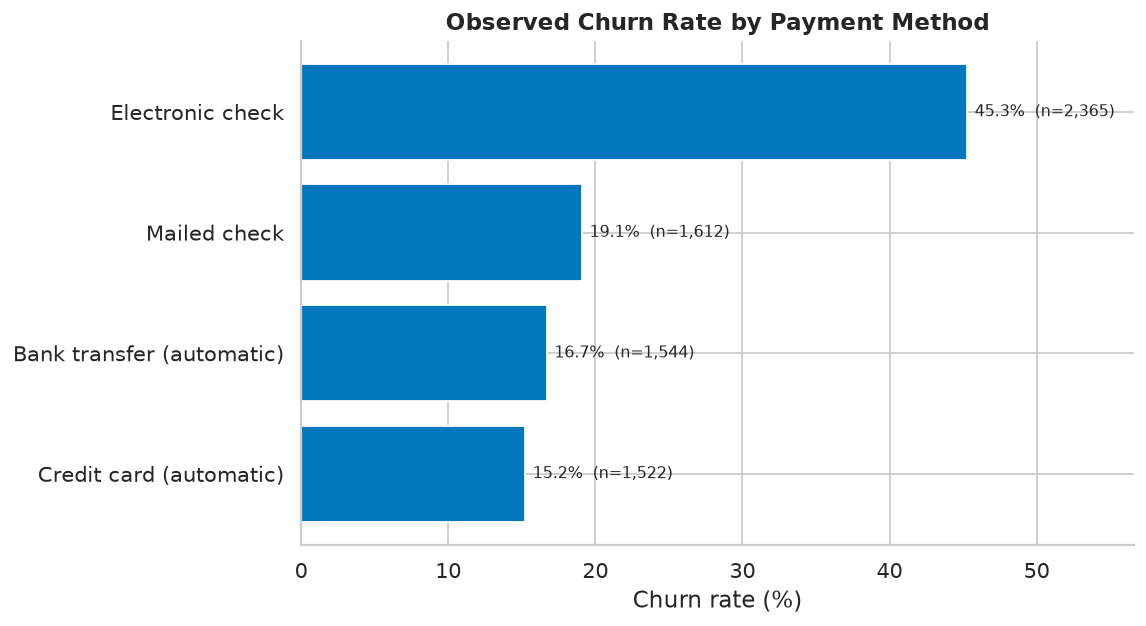

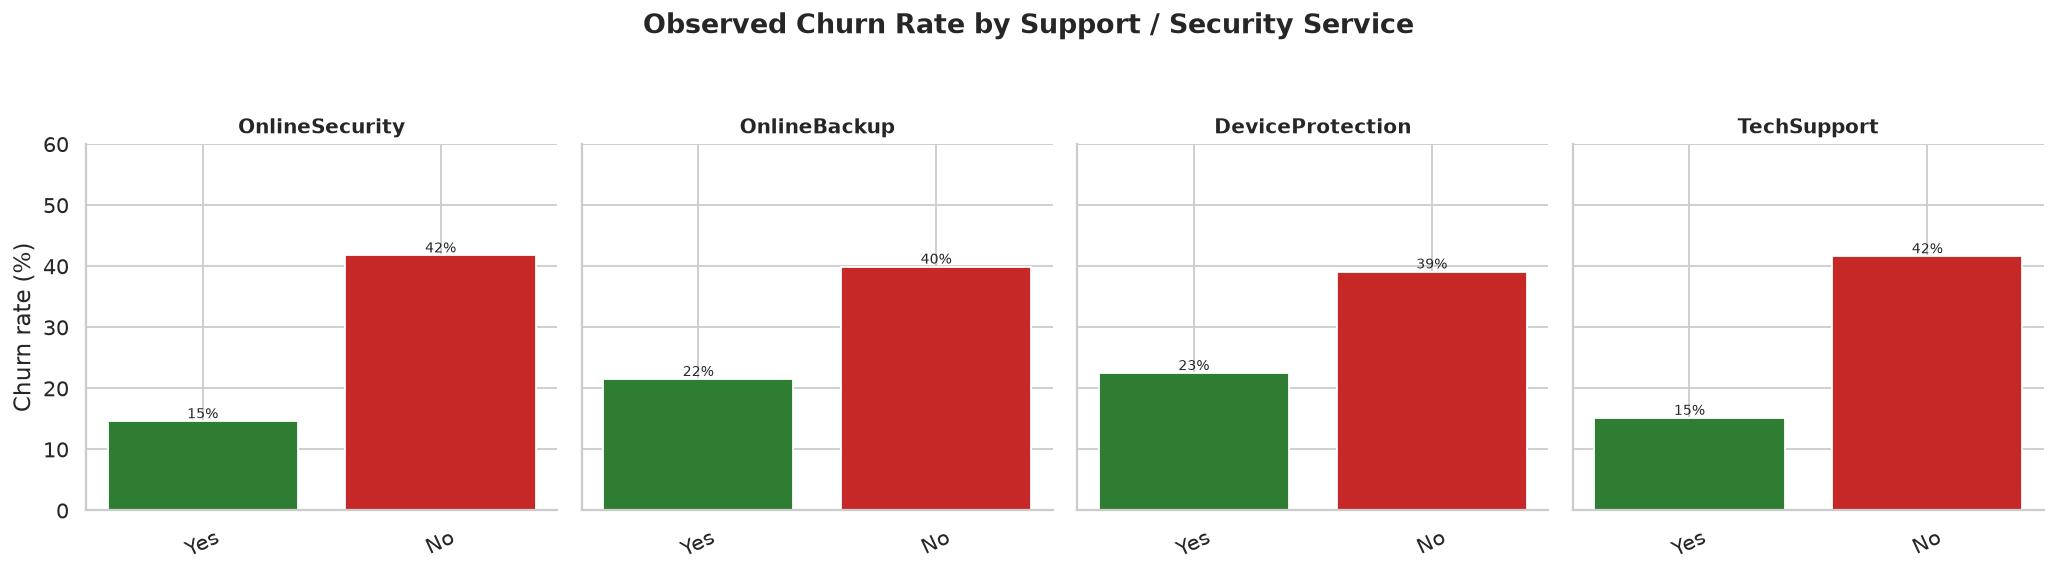

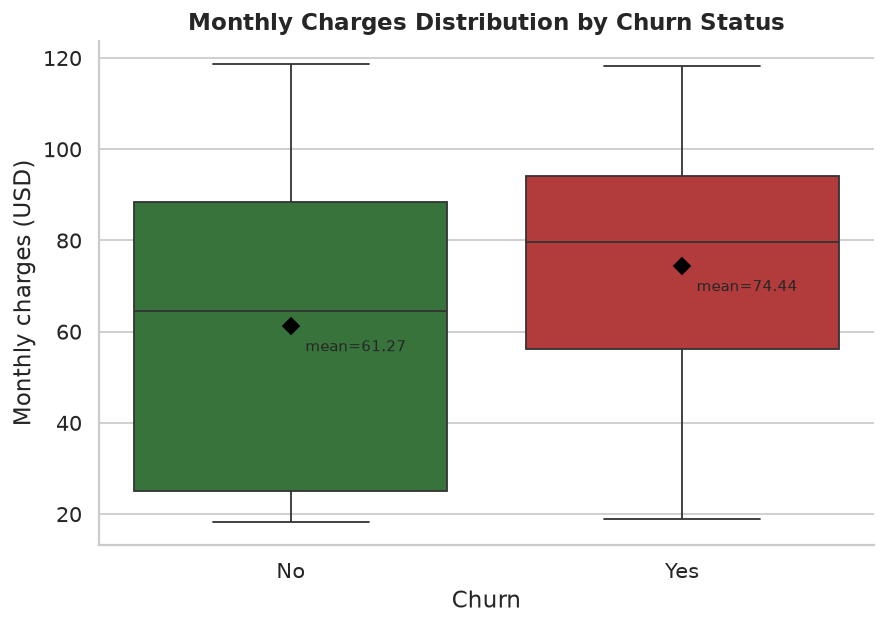

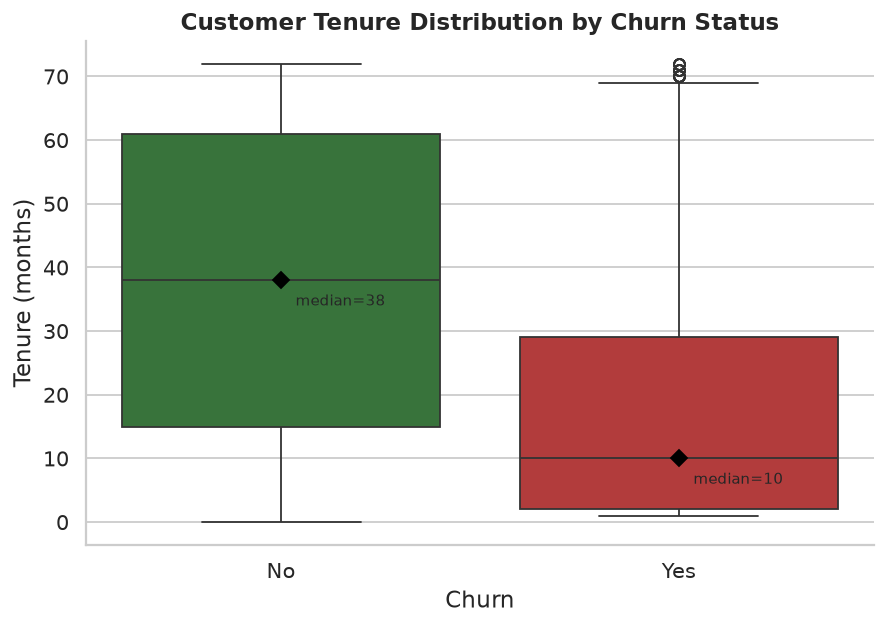

In [8]:
from src.visualization import (
    plot_overall_churn, plot_churn_by_contract, plot_churn_by_tenure,
    plot_churn_by_internet, plot_churn_by_payment, plot_churn_by_support_services,
    plot_monthly_charges_by_churn, plot_tenure_by_churn,
)

for fn in [plot_overall_churn, plot_churn_by_contract, plot_churn_by_tenure,
           plot_churn_by_internet, plot_churn_by_payment,
           plot_churn_by_support_services, plot_monthly_charges_by_churn,
           plot_tenure_by_churn]:
    fn(df)
plt.show()

## Interpretation

- **Contract:** month-to-month customers churned at 42.7%, far above one-year (11.3%) and two-year (2.8%).
- **Tenure:** churn is highest in the first 6 months (52.9%) and falls to 6.6% for 61+ months.
- **Internet:** fiber optic churned at 41.9% vs 19.0% (DSL) and 7.4% (no internet).
- **Payment:** electronic check churned at 45.3% vs automatic methods at ~15-17%.
- **Support/security gaps:** customers without tech support or online security show churn rates around 42% vs ~12% for those with them.
- These are observed associations, not causes.